# Landslide Runout Model

In [1]:
##Importing Librarie
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt 

In [2]:
## For ignoring warnings to view clean output
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [221]:
## Importing the dataset
#df = pd.read_csv('runout_distance.csv',header=0)
xls = pd.ExcelFile('new_lanedslide_dataset.xlsx', engine='openpyxl')
df = pd.read_excel(xls, sheet_name='Rainfall')

In [222]:
df.head(10)

,No.,Place,L(m),H(m),Hs(m),As(m²),At(m²）,V(m³),Wsm(m),Wsa(m),Wa(m),Wm(m),θ(°),α(°),φ(°),β(°),R,reference
0,1,Wenchuan,364.0,265.0,NaN,NaN,NaN,14400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
1,2,Wenchuan,313.0,162.0,NaN,NaN,NaN,10500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
2,3,Wenchuan,420.0,167.0,NaN,NaN,NaN,22200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
3,4,Wenchuan,871.0,468.0,NaN,NaN,NaN,88100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
4,5,Wenchuan,1169.0,614.0,NaN,NaN,NaN,50900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
5,6,Wenchuan,978.0,611.0,NaN,NaN,NaN,45200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
6,7,Wenchuan,883.0,446.0,NaN,NaN,NaN,117500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
7,8,Wenchuan,521.0,257.0,NaN,NaN,NaN,13600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
8,9,Wenchuan,480.0,223.0,NaN,NaN,NaN,22500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."
9,10,Wenchuan,546.0,333.0,NaN,NaN,NaN,25100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Chen, H. X., Zhang, L. M., Gao, L., Zhu, H., &..."


In [223]:
#delete some invalid columns
cols_to_keep = ['L(m)','H(m)','V(m³)','As(m²)','θ(°)','Wsm(m)']#'β(°)',,,,,,,,,'Wsa(m)',,,,'R''Hs(m)',
df = df[cols_to_keep]
df_clean = df.dropna() # delete NAN rows
df_clean = df_clean[df_clean['V(m³)'] >= 1]
valid_rows = len(df_clean)
print(f"valid rows：{valid_rows}")

valid rows：13283


In [122]:
#df_new = df_clean.copy()
#df_new['H_div_L'] = df_new['H(m)'] / (df_new['L(m)'] + 1e-6)
#cols_to_keep = ['H_div_L','V(m³)','As(m²）','θ(°)','β(°)']#',,,'Wsm(m)','Hs(m)''θ(°)''As(m²）',
#df_new = df_new[cols_to_keep]
#df_new = df_new.dropna() # delete NAN rows
#valid_sum = len(df_new)
#print(f"valid rows：{valid_sum}")

In [224]:
df_clean.head()
#df_new.head()

,L(m),H(m),V(m³),As(m²),θ(°),Wsm(m)
61,11.871319,8.0,39.059619,52.5,29.0,7.5
62,32.270463,18.0,83.296454,92.0,38.0,11.5
63,129.961769,53.0,187.793465,168.0,29.0,14.0
64,11.047259,5.0,30.773299,44.0,39.0,8.0
65,39.289532,21.0,64.931567,76.5,27.0,9.0


In [225]:
df_clean.shape
#df_new.shape

(13283, 6)

## Correlation

In [226]:
df_clean.corr()
#df_new.corr()

,L(m),H(m),V(m³),As(m²),θ(°),Wsm(m)
L(m),1.000000,0.943143,0.303331,0.345958,0.010215,0.330715
H(m),0.943143,1.000000,0.336152,0.386028,0.064161,0.367374
V(m³),0.303331,0.336152,1.000000,0.967058,-0.031631,0.720843
As(m²),0.345958,0.386028,0.967058,1.000000,-0.043071,0.827251
θ(°),0.010215,0.064161,-0.031631,-0.043071,1.000000,-0.060895
Wsm(m),0.330715,0.367374,0.720843,0.827251,-0.060895,1.000000


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'L(m)'),
  Text(0, 1.5, 'H(m)'),
  Text(0, 2.5, 'V(m³)'),
  Text(0, 3.5, 'As(m²)'),
  Text(0, 4.5, 'θ(°)'),
  Text(0, 5.5, 'Wsm(m)')])

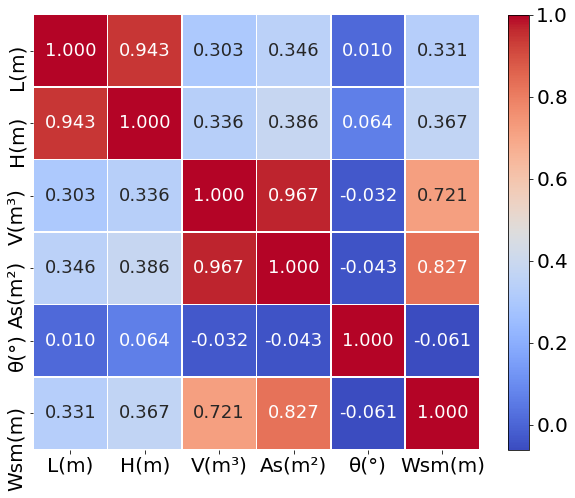

In [227]:
import seaborn as sns
#get correlations of each features in dataset
corrmat = df_clean.corr()
#corrmat = df_new.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(10,8))
#plot heat map
g=sns.heatmap(df_clean[top_corr_features].corr(),annot=True,cmap="coolwarm",annot_kws={'size': 18},fmt='.3f',linewidths=.5,cbar=False)
cb=g.figure.colorbar(g.collections[0])
cb.ax.tick_params(labelsize=20) 
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig("heatmap.png",dpi=400)

### Separating Independent and Dependent feature

In [228]:
X = df_clean.iloc[:,1:]
y = df_clean.iloc[:, 0]
#X = df_new.iloc[:,1:]
#y = df_new.iloc[:, 0]

In [229]:
X.head()

,H(m),V(m³),As(m²),θ(°),Wsm(m)
61,8.0,39.059619,52.5,29.0,7.5
62,18.0,83.296454,92.0,38.0,11.5
63,53.0,187.793465,168.0,29.0,14.0
64,5.0,30.773299,44.0,39.0,8.0
65,21.0,64.931567,76.5,27.0,9.0


In [230]:
X.shape

(13283, 5)

In [231]:
print(min(y))
print(max(y))

0.416576767722453
1758.13259273029


In [232]:
y.head()

61     11.871319
62     32.270463
63    129.961769
64     11.047259
65     39.289532
Name: L(m), dtype: float64

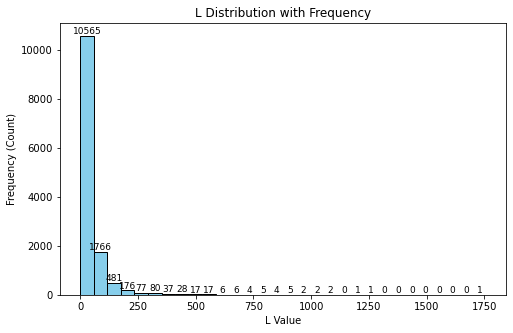

In [233]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
n, bins, patches = plt.hist(y, bins=30, color='skyblue', edgecolor='black')  # 绘制直方图

# 在每个柱子上标注频率
for i in range(len(n)):
    plt.text((bins[i]+bins[i+1])/2, n[i], int(n[i]), ha='center', va='bottom', fontsize=9)

plt.title("L Distribution with Frequency")
plt.xlabel("L Value")
plt.ylabel("Frequency (Count)")
plt.show()


In [234]:
y_log = np.log1p(y)

------------------------------
建议 Log 化: 【是】
判断理由: 原始偏度较高(6.75)，Log变换后有效降低了偏度(0.52)
------------------------------


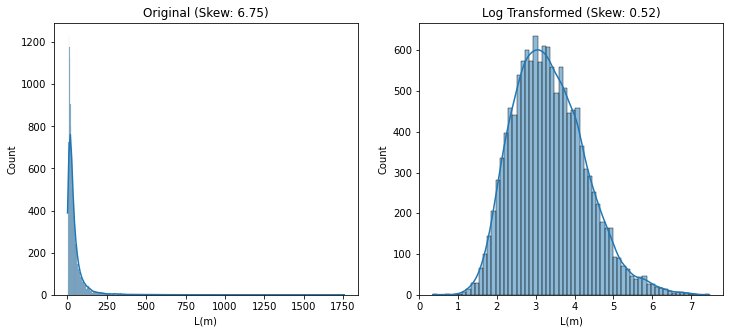

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, normaltest

def evaluate_log_necessity(df):
    """
    自动读取Excel数据并判断是否需要进行Log变换
    """
    
    data = df
    
    # 2. 计算原始数据的统计指标
    orig_skew = skew(data)
    # normaltest 返回 p-value, p < 0.05 表示非正态
    _, orig_p = normaltest(data) 
    
    # 3. 执行 Log 变换 (使用 log1p 兼容处理 0 值)
    log_data = np.log1p(data)
    log_skew = skew(log_data)
    _, log_p = normaltest(log_data)
    
    # 4. 判断逻辑
    # 理由：如果偏度绝对值降低，且更接近正态分布，则建议 Log
    needs_log = False
    reason = ""
    
    if abs(orig_skew) > 0.5: # 偏度阈值通常设为 0.75 或 1
        if abs(log_skew) < abs(orig_skew):
            needs_log = True
            reason = f"原始偏度较高({orig_skew:.2f})，Log变换后有效降低了偏度({log_skew:.2f})"
        else:
            reason = "虽然原始数据偏度高，但Log变换并未改善分布"
    else:
        reason = f"原始数据分布已相对均匀(偏度:{orig_skew:.2f})，无需Log化"

    # 5. 打印结论报告
    print("-" * 30)
    print(f"建议 Log 化: {'【是】' if needs_log else '【否】'}")
    print(f"判断理由: {reason}")
    print("-" * 30)

    # 6. 可视化对比（可选，用于留存证据）
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(data, kde=True, ax=axes[0]).set_title(f"Original (Skew: {orig_skew:.2f})")
    sns.histplot(log_data, kde=True, ax=axes[1]).set_title(f"Log Transformed (Skew: {log_skew:.2f})")
    plt.show()

    return needs_log

# 使用示例
res = evaluate_log_necessity(df_clean['L(m)'])

### Standardization 
Before building the model we need to standardize the features

In [236]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [237]:
## shows the wheather the features are in standardized format or not
print("Mean of the dataset:", np.mean(X).round(8))
print("Standard deviation of the dataset: ", np.std(X).round(8))

Mean of the dataset: 0.0
Standard deviation of the dataset:  1.0


### Splitting the dataset into training and testing set

In [238]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0,shuffle=True)

In [239]:
# print the shapes of our training and test set
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10626, 5)
(2657, 5)
(10626,)
(2657,)


In [240]:
print(X_test)

[[-1.26257208e-01 -9.84975669e-02 -9.16064291e-03 -3.02908258e-01
   2.47240442e-04]
 [ 4.68623566e-01 -1.62273981e-01 -1.10911897e-01  2.63729111e-01
   2.45328945e-01]
 [-7.21137982e-01 -4.53584305e-01 -6.95981606e-01  3.89648526e-01
  -8.57538726e-01]
 ...
 [ 3.12075994e-01  6.12910846e-01  9.40517726e-01 -1.76988843e-01
   1.22565576e+00]
 [-4.08042838e-01 -2.98369724e-01 -3.48331489e-01 -1.81394124e+00
  -4.89916169e-01]
 [ 8.13028224e-01 -2.22931413e-01 -2.12663151e-01  1.27108443e+00
   2.45328945e-01]]


In [241]:
print(y_test)

12967    37.534644
7261     89.754548
10388     6.693723
441      92.428806
207      35.298964
           ...    
7781     47.483932
11699     9.142686
6210     86.714725
5118     22.110089
10124    97.835953
Name: L(m), Length: 2657, dtype: float64


In [242]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [243]:
import numpy as np
import pandas as pd

variables = {"X": X, "X_train": X_train, "X_test": X_test,
             "y_log": y_log, "y_train": y_train_log, "y_test_log": y_test_log,"y":y, "y_test": y_test}

for name, var in variables.items():
    if isinstance(var, np.ndarray):
        n_nan = np.isnan(var).sum()
    elif isinstance(var, (pd.Series, pd.DataFrame)):
        n_nan = var.isna().sum().sum()
    else:
        n_nan = 0
    print(f"{name}: {n_nan} NaN{'s' if n_nan!=1 else ''}")

X: 0 NaNs
X_train: 0 NaNs
X_test: 0 NaNs
y_log: 0 NaNs
y_train: 0 NaNs
y_test_log: 0 NaNs
y: 0 NaNs
y_test: 0 NaNs


In [244]:
use_log = True

if use_log:
    y_train_label = y_train_log
    y_test_label = y_test_log
    y_label = y_log
else:
    y_train_label = y_train
    y_test_label = y_test
    y_label = y

print("Using log-transformed labels" if use_log else "Using original labels")


Using log-transformed labels


### MLP

In [245]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [246]:
# 定义参数网格
param_grid = {
    "hidden_layer_sizes": [(k1, k2, k3) 
                           for k1 in range(10, 200, 40)
                           for k2 in range(10, 200, 40)
                           for k3 in range(10, 200, 40)],
    "alpha":[0.01,0.1]
}#(10,200,40)(0.01,0.1),(5,100,10)(0.1)

mlp = MLPRegressor(
    activation="relu",
    solver="adam",
    max_iter=1000,
    learning_rate="constant",
    early_stopping=True,
    n_iter_no_change=20, 
    random_state=1
)

mlp_grid_search = GridSearchCV(
    mlp,
    param_grid=param_grid,
    scoring="r2",
    cv=KFold(n_splits=5, shuffle=True, random_state=1),
    n_jobs=-1,
    verbose=2,
    return_train_score=True)

mlp_grid_search.fit(X_train, y_train_label)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=MLPRegressor(early_stopping=True, max_iter=1000,
                                    n_iter_no_change=20, random_state=1),
             n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1],
                         'hidden_layer_sizes': [(10, 10, 10), (10, 10, 50),
                                                (10, 10, 90), (10, 10, 130),
                                                (10, 10, 170), (10, 50, 10),
                                                (10, 50, 50), (10, 50, 90),
                                                (10, 50, 130), (10, 50, 170),
                                                (10, 90, 10), (10, 90, 50),
                                                (10, 90, 90), (10, 90, 130),
                                                (10, 90, 170), (10, 130, 10),
                                                (10, 130, 50), (10, 130, 90),
                                                (10, 130, 130), (10, 130, 170),
                                                (10, 170, 10), (10, 170, 50),
                                                (10, 170, 90), (10, 170, 130),
                                                (10, 170, 170), (50, 10, 10),
                                                (50, 10, 50), (50, 10, 90),
                                                (50, 10, 130), (50, 10, 170), ...]},
             return_train_score=True, scoring='r2', verbose=2)

In [247]:
# train 分数
best_idx = mlp_grid_search.best_index_
print("Best train score:", mlp_grid_search.cv_results_["mean_train_score"][best_idx])
mlp_cv_scores =mlp_grid_search.cv_results_["mean_test_score"][best_idx]
mlp_cv_std = mlp_grid_search.cv_results_["std_test_score"][best_idx]
print(f"Best valid score: {mlp_cv_scores:.5f} ± {mlp_cv_std:.5f}")

mlp_best_params = mlp_grid_search.best_params_
print("Best params:", mlp_best_params)

Best train score: 0.947094172641384
Best valid score: 0.94389 ± 0.00302
Best params: {'alpha': 0.01, 'hidden_layer_sizes': (130, 50, 50)}


In [248]:
# 准备 OOF
kf = KFold(n_splits=5, shuffle=True, random_state=1)
folds = np.zeros_like(y_train_label, dtype=int)#为融合模型输出标准差
mlp_oof_preds = np.zeros(len(y_train_label),dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, y_tr = X_train[train_idx], y_train_label.iloc[train_idx]
    X_val, y_val = X_train[val_idx], y_train_label.iloc[val_idx]
    
    folds[val_idx] = fold

    # 用最佳参数组合初始化模型
    mlp = MLPRegressor(
    activation="relu",
    solver="adam",
    max_iter=1000,
    learning_rate="constant",
    early_stopping=True,
    n_iter_no_change=20, 
    random_state=1,
    **mlp_best_params
    )
#     mlp = MLPRegressor(
#     activation="relu",
#     solver="adam",
#     max_iter=1000,
#     learning_rate="constant",
#     early_stopping=True,
#     n_iter_no_change=20, 
#     random_state=1,
#     alpha=0.1,
#     hidden_layer_sizes=(130,50,10)
#     )
    mlp.fit(X_tr, y_tr)

    # OOF 预测
    mlp_oof_preds[val_idx] = mlp.predict(X_val)
    
mlp_oof_r2 = r2_score(y_train_label, mlp_oof_preds)
print(mlp_oof_preds)
print(f"OOF r2: {mlp_oof_r2:.4f}")

[3.56752516 3.36248169 3.32149565 ... 3.38460509 3.7098012  3.86321183]
OOF r2: 0.9440


In [249]:
# predicting the values for x-test
# you can fine select parameter
mx = MLPRegressor( **mlp_best_params, activation='relu',solver='adam',n_iter_no_change=20, 
                   max_iter=1000,learning_rate='constant',random_state=1) 
# mx = MLPRegressor( hidden_layer_sizes=(130,50,10),alpha=0.1,activation='relu',solver='adam',n_iter_no_change=20, 
#                    max_iter=1000,learning_rate='constant',random_state=1) 
mx.fit(X_train, y_train_label)
mlp_predictions=mx.predict(X_test)
#mlp_predictions = np.expm1(mlp_predictions_log)

In [250]:
print(mlp_predictions)

[3.6298505  4.20890936 1.80397568 ... 4.15518586 3.25090646 4.48752762]


In [251]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test_label, mlp_predictions))
print('MSE:', metrics.mean_squared_error(y_test_label, mlp_predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test_label, mlp_predictions)))
mlp_test_r2 = metrics.r2_score(y_test_label, mlp_predictions)
print("r2:", mlp_test_r2)

MAE: 0.17229808026671395
MSE: 0.05111027682223563
RMSE: 0.22607582095888898
r2: 0.9419750543770933


In [252]:
mx.score(X,y_label)

0.9459196624797418

In [253]:
#检验训练数据拟合程度
pred_mlp_train = mx.predict(X_train)

In [254]:
mlp_mae_train=metrics.mean_absolute_error(y_train_label, pred_mlp_train)
mlp_mse_train=metrics.mean_squared_error(y_train_label, pred_mlp_train)
mlp_rmse_train=np.sqrt(metrics.mean_squared_error(y_train_label, pred_mlp_train))
R2_mlp_train=metrics.r2_score(y_train_label,pred_mlp_train)

In [255]:
print('MAE:', mlp_mae_train)
print('MSE:', mlp_mse_train)
print('RMSE:', mlp_rmse_train)
print('R2:',R2_mlp_train)

MAE: 0.1632158155927863
MSE: 0.04542555417025444
RMSE: 0.21313271492254407
R2: 0.9469344517850037


### Model Building with Random Forest Regressor

In [256]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
import time
from sklearn.metrics import r2_score

RF = RandomForestRegressor(random_state=1)

In [257]:
n_estimators = [int(x) for x in np.linspace(start = 25,stop = 500,num = 20)]#(5,100,20),(25,500,20)
max_depth = [1,3,5,7]#1,3,5,7(1,3)
min_samples_leaf = [1,5,10]#(1,5,10)(5,10)
max_features = ['sqrt',1.0]
random_params_group = {'n_estimators':n_estimators,
                      'max_depth':max_depth,
                      'max_features':max_features,
                      'min_samples_leaf':min_samples_leaf}
random_model =RandomizedSearchCV(RF,param_distributions = random_params_group,n_iter = 100,
scoring = 'r2',verbose = 2,n_jobs = -1,cv = KFold(n_splits=5, shuffle=True, random_state=1),
                                 random_state = 1,return_train_score=True)
# 使用该模型训练数据
random_model.fit(X_train, y_train_label)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=RandomForestRegressor(random_state=1), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': [1, 3, 5, 7],
                                        'max_features': ['sqrt', 1.0],
                                        'min_samples_leaf': [1, 5, 10],
                                        'n_estimators': [25, 50, 75, 100, 125,
                                                         150, 175, 200, 225,
                                                         250, 275, 300, 325,
                                                         350, 375, 400, 425,
                                                         450, 475, 500]},
                   random_state=1, return_train_score=True, scoring='r2',
                   verbose=2)

In [258]:
RF_best_params = random_model.best_params_
print("Best params:", RF_best_params)

best_idx = random_model.best_index_
print("Best train score:", random_model.cv_results_['mean_train_score'][best_idx])
RF_cv_scores =random_model.cv_results_['mean_test_score'][best_idx]
RF_cv_std = random_model.cv_results_["std_test_score"][best_idx]
print(f"Best valid score: {RF_cv_scores:.5f} ± {RF_cv_std:.5f}")

Best params: {'n_estimators': 250, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 7}
Best train score: 0.9500695666099611
Best valid score: 0.94241 ± 0.00385


In [259]:
# 准备 OOF
kf = KFold(n_splits=5, shuffle=True, random_state=1)
RF_oof_preds = np.zeros(len(y_train_label),dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, y_tr = X_train[train_idx], y_train_label.iloc[train_idx]
    X_val, y_val = X_train[val_idx], y_train_label.iloc[val_idx]

    # 用最佳参数组合初始化模型
    RF_model=RandomForestRegressor(**RF_best_params,random_state=1)
    #RF_model=RandomForestRegressor(n_estimators =125,max_depth =7,min_samples_leaf =5,max_features =1.0,random_state=1)
    RF_model.fit(X_tr, y_tr)

    # OOF 预测
    RF_oof_preds[val_idx] = RF_model.predict(X_val)
    
RF_oof_r2 = r2_score(y_train_label, RF_oof_preds)
print(f"OOF r2: {RF_oof_r2:.4f}")

OOF r2: 0.9425


In [260]:
start_time = time.time()
RF=RandomForestRegressor(**RF_best_params,random_state=1)
#RF_model=RandomForestRegressor(n_estimators =125,max_depth =7,min_samples_leaf =5,max_features =1.0,random_state=1)
# feeding the training data into the model
RF.fit(X_train, y_train_label)
print("Execution time: " + str((time.time() - start_time)) + ' sec')

Execution time: 6.4003660678863525 sec


In [261]:
# predicting the values for x-test
RF_predictions=RF.predict(X_test)

In [262]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test_label, RF_predictions))
print('MSE:', metrics.mean_squared_error(y_test_label, RF_predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test_label, RF_predictions)))
RF_test_r2 = metrics.r2_score(y_test_label, RF_predictions)
print("r2:", RF_test_r2)

MAE: 0.1722995764025171
MSE: 0.051777072551057186
RMSE: 0.22754575924648032
r2: 0.9412180483831515


In [263]:
pred_rf_train=RF.predict(X_train)

In [264]:
rf_mae_train=metrics.mean_absolute_error(y_train_label, pred_rf_train)
rf_mse_train=metrics.mean_squared_error(y_train_label, pred_rf_train)
rf_rmse_train=np.sqrt(metrics.mean_squared_error(y_train_label, pred_rf_train))
R2_rf_train=metrics.r2_score(y_train_label,pred_rf_train)

In [265]:
print('MAE:', rf_mae_train)
print('MSE:', rf_mse_train)
print('RMSE:', rf_rmse_train)
print('R2:',R2_rf_train)

MAE: 0.15864391762123684
MSE: 0.04336644880601313
RMSE: 0.20824612554862368
R2: 0.9493398721916844


In [266]:
RF.score(X,y_label)

0.947677919550569

In [267]:
# 计算特征重要性
importances = RF.feature_importances_
std = np.std([tree.feature_importances_ for tree in RF.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

In [268]:
print("Feature ranking:")
for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

Feature ranking:
1. feature 0 (0.982124)
2. feature 3 (0.011870)
3. feature 2 (0.002556)
4. feature 1 (0.002311)
5. feature 4 (0.001140)


### XGB

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'D:\data box\Anaconda\envs\landslide_runout\Scripts\python.exe -m pip install --upgrade pip' command.


In [269]:
import xgboost as xgb
import time
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

xgb_reg = xgb.XGBRegressor(random_state=1)

In [270]:
param_grid = [
{'n_estimators': [50,100,300,500],'max_depth': [1,3,5,7],'min_child_weight':[1,5,8],'learning_rate': [0.05,0.1,0.2],'reg_alpha':[1,5,10,15]} ]
#(50,100,300,500) (1,3,5,7) (1,5,8) (0.05,0.1,0.2) (1,5,10,15) #(20,50,100)(1,3)(5,10)(0.05,0.1,0.2)(5,10,15)
xgb_grid_search = GridSearchCV(xgb_reg, param_grid, cv=KFold(n_splits=5, shuffle=True, random_state=1),
                          scoring='r2',return_train_score=True)
xgb_grid_search.fit(X_train, y_train_label)

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    inter...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=1, ...),
             param_grid=[{'learning_rate': [0.05, 0.1, 0.2],
                          'max_depth': [1, 3, 5, 7],
                          'min_child_weight': [1, 5, 8],
                          'n_estimators': [50, 100, 300, 500],
                          'reg_alpha': [1, 5, 10, 15]}],
             return_train_score=True, scoring='r2')

In [271]:
xgb_best_params = xgb_grid_search.best_params_
print("Best params:", xgb_best_params)

best_idx = xgb_grid_search.best_index_
print("Best train score:", xgb_grid_search.cv_results_['mean_train_score'][best_idx])
xgb_grid_search_cv_scores =xgb_grid_search.cv_results_['mean_test_score'][best_idx]
xgb_grid_search_cv_std = xgb_grid_search.cv_results_["std_test_score"][best_idx]
print(f"Best valid score: {xgb_grid_search_cv_scores:.5f} ± {xgb_grid_search_cv_std:.5f}")

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 8, 'n_estimators': 300, 'reg_alpha': 1}
Best train score: 0.9502871586253591
Best valid score: 0.94369 ± 0.00296


In [272]:
# 准备 OOF
kf = KFold(n_splits=5, shuffle=True, random_state=1)
xgb_oof_preds = np.zeros(len(y_train_label),dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, y_tr = X_train[train_idx], y_train_label.iloc[train_idx]
    X_val, y_val = X_train[val_idx], y_train_label.iloc[val_idx]

    # 用最佳参数组合初始化模型
    xgb_model = xgb.XGBRegressor(random_state=1,**xgb_best_params)
    #xgb_model = xgb.XGBRegressor(random_state=1,n_estimators=300,max_depth=3,learning_rate=0.1,min_child_weight=5,reg_alpha=1)
    xgb_model.fit(X_tr, y_tr)

    # OOF 预测
    xgb_oof_preds[val_idx] = xgb_model.predict(X_val)
    
xgb_oof_r2 = r2_score(y_train_label, xgb_oof_preds)
print(f"OOF r2: {xgb_oof_r2:.4f}")

OOF r2: 0.9438


In [273]:
start_time = time.time()
Xgb = xgb.XGBRegressor(random_state=1,**xgb_best_params)
#Xgb = xgb.XGBRegressor(random_state=1,n_estimators=300,max_depth=3,learning_rate=0.1,min_child_weight=5,reg_alpha=1)
Xgb.fit(X_train, y_train_label) 
print("Execution time: " + str((time.time() - start_time)) + ' sec')

Execution time: 2.5711469650268555 sec


In [274]:
xgb_pred=Xgb.predict(X_test)

In [275]:
print(xgb_pred)

[3.602589  4.246425  1.7915503 ... 4.1266627 3.2268481 4.376732 ]


In [276]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test_label, xgb_pred))
print('MSE:', metrics.mean_squared_error(y_test_label, xgb_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test_label, xgb_pred)))
R2_Xgb=metrics.r2_score(y_test_label,xgb_pred)
print('r2:',R2_Xgb)

MAE: 0.1688710057993943
MSE: 0.0498992937167735
RMSE: 0.22338149815231675
r2: 0.9433498704261062


In [277]:
Xgb.score(X_train,y_train_label)

0.9496888448069782

In [278]:
Xgb.score(X_test,y_test_label)

0.9433498704261062

In [279]:
pred_Xgb=Xgb.predict(X)

In [280]:
Xgb_mae=metrics.mean_absolute_error(y_label, pred_Xgb)
Xgb_mse=metrics.mean_squared_error(y_label, pred_Xgb)
Xgb_rmse=np.sqrt(metrics.mean_squared_error(y_label, pred_Xgb))
R2_Xgb=metrics.r2_score(y_label,pred_Xgb)

In [281]:
print('MAE:', Xgb_mae)
print('MSE:', Xgb_mse)
print('RMSE:', Xgb_rmse)
print('R2:',R2_Xgb)

MAE: 0.16061206293617775
MSE: 0.044434239463452506
RMSE: 0.2107943060508336
R2: 0.948391733691593


In [282]:
importance_gain = Xgb.get_booster().get_score(importance_type='gain')
print("Gain:", importance_gain)

Gain: {'f0': 65.75691986083984, 'f1': 1.035963773727417, 'f3': 0.8358708024024963, 'f4': 0.12162168323993683}


### SVR

In [283]:
#SVM构建
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

svr = SVR(kernel='rbf')

In [284]:
 param_grid = {
    'epsilon': [0.01,0.1, 0.5],
    'C': [0.1, 1,10],
    'gamma': [0.01, 0.1,0.5]
}#(0.01,0.1,0.5)(0.1,1,10)(0.01,0.1,0.5) #(0.1,0.5)(0.1,1)(0.01,0.1)

svr_grid = GridSearchCV(svr, param_grid, cv=KFold(n_splits=5, shuffle=True, random_state=1), 
                    scoring='r2',return_train_score=True)
svr_grid.fit(X_train, y_train_label)

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=SVR(),
             param_grid={'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1, 0.5],
                         'gamma': [0.01, 0.1, 0.5]},
             return_train_score=True, scoring='r2')

In [285]:
svr_best_params = svr_grid.best_params_
print("Best params:", svr_best_params)

best_idx = svr_grid.best_index_
print("Best train score:", svr_grid.cv_results_['mean_train_score'][best_idx])
svr_cv_scores =svr_grid.cv_results_['mean_test_score'][best_idx]
svr_cv_std = svr_grid.cv_results_["std_test_score"][best_idx]
print(f"Best valid score: {svr_cv_scores:.5f} ± {svr_cv_std:.5f}")

Best params: {'C': 10, 'epsilon': 0.01, 'gamma': 0.1}
Best train score: 0.9455728097932813
Best valid score: 0.93888 ± 0.00299


In [286]:
# 准备 OOF
kf = KFold(n_splits=5, shuffle=True, random_state=1)
svr_oof_preds = np.zeros(len(y_train_label),dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, y_tr = X_train[train_idx], y_train_label.iloc[train_idx]
    X_val, y_val = X_train[val_idx], y_train_label.iloc[val_idx]

    # 用最佳参数组合初始化模型
    SVR_model = SVR(kernel= "rbf",**svr_best_params)
    #SVR_model = SVR(kernel= "rbf",epsilon=0.01,C=10,gamma=0.1)
    SVR_model.fit(X_tr, y_tr)

    # OOF 预测
    svr_oof_preds[val_idx] = SVR_model.predict(X_val)
    
svr_oof_r2 = r2_score(y_train_label, svr_oof_preds)
print(f"OOF r2: {svr_oof_r2:.5f}")

OOF r2: 0.93895


In [287]:
svr_model = SVR(kernel= "rbf",**svr_best_params)
#svr_model = SVR(kernel= "rbf",epsilon=0.01,C=10,gamma=0.1)

In [288]:
svr_model.fit(X_train,y_train_label)

SVR(C=10, epsilon=0.01, gamma=0.1)

In [289]:
# predicting the values for x-test
svr_pred=svr_model.predict(X_test)

In [290]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test_label, svr_pred))
print('MSE:', metrics.mean_squared_error(y_test_label, svr_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test_label, svr_pred)))
svr_test_r2 = metrics.r2_score(y_test_label, svr_pred)
print("r2:", svr_test_r2)

MAE: 0.17359345276395072
MSE: 0.05471386833548368
RMSE: 0.23390995775187443
r2: 0.9378839358270874


In [291]:
svr_model.score(X,y_label)

0.9440027413631898

In [292]:
y_pred=svr_model.predict(X_test)

In [293]:
pred_svr_train=svr_model.predict(X_train)

In [294]:
svr_mae_train=metrics.mean_absolute_error(y_train_label, pred_svr_train)
svr_mse_train=metrics.mean_squared_error(y_train_label, pred_svr_train)
svr_rmse_train=np.sqrt(metrics.mean_squared_error(y_train_label, pred_svr_train))
R2_svr_train=metrics.r2_score(y_train_label,pred_svr_train)

In [295]:
print('MAE:', svr_mae_train)
print('MSE:', svr_mse_train)
print('RMSE:', svr_rmse_train)
print('R2:',R2_svr_train)

MAE: 0.16256451202247577
MSE: 0.04658762855443311
RMSE: 0.21584167473968763
R2: 0.945576931433531


## TabNet

In [1]:
pip install pytorch-tabnet

Note: you may need to restart the kernel to use updated packages.


'D:\data' 不是内部或外部命令，也不是可运行的程序
或批处理文件。


In [296]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import random
import torch.nn.functional as F
from sklearn.metrics import r2_score

# --------------------------
# 1️⃣ 固定随机性
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# 5折 CV
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

In [297]:
# --------------------------
#  TabNet 网格搜索 + 五折 CV
tabnet_param_grid = {
    'n_d': [8,16],
    'n_a': [8,16],
    'n_steps': [3,5]
}

best_tabnet_score = -float('inf')
best_tabnet_params = None

print("=== TabNet Grid Search ===")
for n_d in tabnet_param_grid['n_d']:
    for n_a in tabnet_param_grid['n_a']:
        for n_steps in tabnet_param_grid['n_steps']:
            fold_train_scores = []
            fold_valid_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_tr, X_val = X_train[train_idx], X_train[val_idx]
                y_tr = y_train_label.iloc[train_idx].values.reshape(-1, 1)
                y_val = y_train_label.iloc[val_idx].values.reshape(-1, 1)

                model = TabNetRegressor(
                    n_d=n_d, n_a=n_a, n_steps=n_steps,
                    gamma=1.3, mask_type='sparsemax',
                    verbose=0, seed=seed
                )

                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_val, y_val)],
                    eval_metric=['mse'],
                    loss_fn=F.mse_loss,
                    max_epochs=200,
                    patience=20,
                    batch_size=512,
                    virtual_batch_size=256
                )

                y_tr_pred = model.predict(X_tr)
                y_val_pred = model.predict(X_val)

                fold_train_scores.append(r2_score(y_tr, y_tr_pred))
                fold_valid_scores.append(r2_score(y_val, y_val_pred))

            mean_train = np.mean(fold_train_scores)
            std_train = np.std(fold_train_scores, ddof=1)  # ddof=1 计算样本标准差
            mean_valid = np.mean(fold_valid_scores)
            std_valid = np.std(fold_valid_scores, ddof=1)
            print(
                f"n_d={n_d}, n_a={n_a}, n_steps={n_steps} | "
                f"Train R²={mean_train:.=5f} ± {std_train:.5f}, "
                f"Valid R²={mean_valid:.5f} ± {std_valid:.5f}"
                )

            if mean_valid > best_tabnet_score:
                best_tabnet_score = mean_valid
                best_tabnet_params = (n_d, n_a, n_steps)

print("Best TabNet params:", best_tabnet_params)
print("Best TabNet Valid R² (CV):", best_tabnet_score)

=== TabNet Grid Search ===

Early stopping occurred at epoch 50 with best_epoch = 30 and best_val_0_mse = 0.04641

Early stopping occurred at epoch 35 with best_epoch = 15 and best_val_0_mse = 0.05352

Early stopping occurred at epoch 62 with best_epoch = 42 and best_val_0_mse = 0.05436

Early stopping occurred at epoch 89 with best_epoch = 69 and best_val_0_mse = 0.05118

Early stopping occurred at epoch 89 with best_epoch = 69 and best_val_0_mse = 0.04941
n_d=8, n_a=8, n_steps=3 | Train R²=0.940723 ± 0.00289, Valid R²=0.94036 ± 0.00466

Early stopping occurred at epoch 62 with best_epoch = 42 and best_val_0_mse = 0.04566

Early stopping occurred at epoch 87 with best_epoch = 67 and best_val_0_mse = 0.04861

Early stopping occurred at epoch 68 with best_epoch = 48 and best_val_0_mse = 0.05136

Early stopping occurred at epoch 64 with best_epoch = 44 and best_val_0_mse = 0.04959

Early stopping occurred at epoch 78 with best_epoch = 58 and best_val_0_mse = 0.05121
n_d=8, n_a=8, n_steps

In [298]:
n_d_best, n_a_best, n_steps_best = best_tabnet_params
#n_d_best, n_a_best, n_steps_best = (16,8,3)
tabnet_oof_preds = np.zeros_like(y_train_label.values, dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"OOF Fold {fold+1}")
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr = y_train_label.iloc[train_idx].values.reshape(-1, 1)
    y_val = y_train_label.iloc[val_idx].values.reshape(-1, 1)

    model = TabNetRegressor(
        n_d=n_d_best, n_a=n_a_best, n_steps=n_steps_best,
        gamma=1.3, mask_type='sparsemax',
        verbose=0, seed=seed
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric=['mse'],
        loss_fn=F.mse_loss,
        max_epochs=200,
        patience=20,
        batch_size=512,
        virtual_batch_size=256
    )

    tabnet_oof_preds[val_idx] = model.predict(X_val).flatten()

# 计算 OOF R²
oof_r2 = r2_score(y_train_label, tabnet_oof_preds)
print(f"TabNet OOF R²: {oof_r2:.5f}")

OOF Fold 1

Early stopping occurred at epoch 58 with best_epoch = 38 and best_val_0_mse = 0.04521
OOF Fold 2

Early stopping occurred at epoch 61 with best_epoch = 41 and best_val_0_mse = 0.04915
OOF Fold 3

Early stopping occurred at epoch 108 with best_epoch = 88 and best_val_0_mse = 0.05232
OOF Fold 4

Early stopping occurred at epoch 67 with best_epoch = 47 and best_val_0_mse = 0.04973
OOF Fold 5

Early stopping occurred at epoch 67 with best_epoch = 47 and best_val_0_mse = 0.04929
TabNet OOF R²: 0.94260


In [299]:
from sklearn.metrics import r2_score

# --------------------------
# TabNet 最终训练 + 测试集预测
best_n_d, best_n_a, best_n_steps = best_tabnet_params
#best_n_d, best_n_a, best_n_steps =(16,8,3)

final_tabnet = TabNetRegressor(
    n_d=best_n_d, n_a=best_n_a, n_steps=best_n_steps,
    gamma=1.3, mask_type='sparsemax',
    verbose=0, seed=seed
)

y_train_Tab = y_train_label.values.reshape(-1, 1)
y_test_Tab = y_test_label.values.reshape(-1, 1)
final_tabnet.fit(
    X_train, y_train_Tab,
    loss_fn=F.mse_loss,
    max_epochs=100,
    patience=0,
    batch_size=512,
    virtual_batch_size=256
)

y_test_pred_tabnet = final_tabnet.predict(X_test)
r2_tabnet = r2_score(y_test_label, y_test_pred_tabnet)
print(f"TabNet Test R²: {r2_tabnet:.5f}")

y_pred_tabnet = final_tabnet.predict(X)
r2_tabnet = r2_score(y_label, y_pred_tabnet)
print(f"TabNet all data R²: {r2_tabnet:.5f}")


Early stopping occurred at epoch 97 with best_epoch = 77 and best_val_0_mse = 0.05176
TabNet Test R²: 0.94124
TabNet all data R²: 0.94234


## FT-Transformer

In [35]:
pip install pytorch-tabular

Looking in indexes: http://mirrors.aliyun.com/pypi/simple, http://mirrors.aliyun.com/pypi/simpleNote: you may need to restart the kernel to use updated packages.



  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 1.3.8
    Uninstalling pytorch-lightning-1.3.8:
      Successfully uninstalled pytorch-lightning-1.3.8


In [300]:
import torch
from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, TrainerConfig,OptimizerConfig
from pytorch_tabular.models.ft_transformer.config import FTTransformerConfig
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import logging
logging.disable(logging.CRITICAL)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # 忽略所有 UserWarning
warnings.filterwarnings("ignore", category=FutureWarning)  # 忽略 FutureWarning

In [302]:
# ========================
# 参数搜索范围（小数据集合理配置）
# ========================
ft_param_grid = {
    "input_embed_dim": [16,32],
    "num_heads": [2,4],
    "num_attn_blocks": [2,3],
    "attn_dropout": [0.0],
    "ff_dropout": [0.0]
}

kf = KFold(n_splits=5, shuffle=True, random_state=1)

ft_best_score = -float("inf")
best_params = None

# ========================
# 网格搜索
# ========================
for d_token in ft_param_grid["input_embed_dim"]:
    for n_heads in ft_param_grid["num_heads"]:
        for n_blocks in ft_param_grid["num_attn_blocks"]:
            for attn_dp in ft_param_grid["attn_dropout"]:
                for ff_dp in ft_param_grid["ff_dropout"]:
                    
                    fold_train_scores = []
                    fold_valid_scores = []

                    for train_idx, val_idx in kf.split(X_train):
                        # 取出本折数据
                        X_tr, X_val = X_train[train_idx], X_train[val_idx]
                        y_tr, y_val = y_train_label.iloc[train_idx], y_train_label.iloc[val_idx]     
                        
                        
                        # 转换成 DataFrame
                        df_tr = pd.DataFrame(X_tr, columns=[f'feat{i}' for i in range(X_train.shape[1])])
                        df_tr['target'] = y_tr.values
                        df_val = pd.DataFrame(X_val, columns=[f'feat{i}' for i in range(X_train.shape[1])])
                        df_val['target'] = y_val.values
                        
                        # 配置
                        data_config = DataConfig(
                            target=['target'], 
                            continuous_cols=[f'feat{i}' for i in range(X_train.shape[1])]
                        )
                        model_config = FTTransformerConfig(
                            task="regression",
                            metrics=["mean_squared_error"],
                            input_embed_dim=d_token,
                            num_heads=n_heads,
                            num_attn_blocks=n_blocks,
                            attn_dropout=attn_dp,
                            ff_dropout=ff_dp,
                            seed=1
                        )
                        
                        optimizer_config = OptimizerConfig()
                        
                        trainer_config = TrainerConfig(
                            max_epochs=50, 
                            batch_size=512,
                            early_stopping="valid_loss",
                            early_stopping_patience=10,
                            track_grad_norm=-1,
                            profiler=None,
                            precision=16,
                            seed=1,
                            progress_bar='none',
                            check_val_every_n_epoch=5,
                            trainer_kwargs={
                                "enable_model_summary": False,  # 训练开始时不打印模型 summary
                                "log_every_n_steps": 0          # 控制日志频率（旧版 Lightning 可能不同）
                            }
                            )

                        ft_model = TabularModel(
                            data_config=data_config, 
                            model_config=model_config, 
                            trainer_config=trainer_config,
                            optimizer_config=optimizer_config
                        )

                        ft_model.fit(train=df_tr, validation=df_val)

                        # 预测
                        y_tr_pred = ft_model.predict(df_tr)
                        y_val_pred = ft_model.predict(df_val)

                        # MSE
                        fold_train_scores.append(r2_score(y_tr, y_tr_pred))
                        fold_valid_scores.append(r2_score(y_val, y_val_pred))

                        
                        
                    mean_train = np.mean(fold_train_scores)
                    std_train = np.std(fold_train_scores, ddof=1)  # ddof=1 计算样本标准差
                    mean_valid = np.mean(fold_valid_scores)
                    std_valid = np.std(fold_valid_scores, ddof=1)

                    print(f"input_embed_dim={d_token}, num_heads={n_heads}, num_attn_blocks={n_blocks}, "
                          f"attn_dropout={attn_dp}, ff_dropout={ff_dp} | "
                          f"Train r2={mean_train:.5f}± {std_train:.5f}, Valid r2={mean_valid:.5f}± {std_valid:.5f}")

                    # 更新最优
                    if mean_valid > ft_best_score:
                        ft_best_score = mean_valid
                        ft_best_params = (d_token, n_heads, n_blocks, attn_dp, ff_dp)

print("\nBest Params:", ft_best_params)
print("Best CV Valid r2:", ft_best_score)

input_embed_dim=16, num_heads=2, num_attn_blocks=2, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93035± 0.00280, Valid r2=0.92964± 0.00260
input_embed_dim=16, num_heads=2, num_attn_blocks=3, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93541± 0.00073, Valid r2=0.93496± 0.00413
input_embed_dim=16, num_heads=4, num_attn_blocks=2, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93595± 0.00172, Valid r2=0.93536± 0.00615
input_embed_dim=16, num_heads=4, num_attn_blocks=3, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93723± 0.00220, Valid r2=0.93660± 0.00571
input_embed_dim=32, num_heads=2, num_attn_blocks=2, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93848± 0.00104, Valid r2=0.93834± 0.00453
input_embed_dim=32, num_heads=2, num_attn_blocks=3, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93787± 0.00103, Valid r2=0.93770± 0.00563
input_embed_dim=32, num_heads=4, num_attn_blocks=2, attn_dropout=0.0, ff_dropout=0.0 | Train r2=0.93906± 0.00118, Valid r2=0.93880± 0.00467
input_embed_dim=32, 

In [303]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# =============================
# 最佳参数（假设已经网格搜索得到）
# =============================
#ft_best_params=(32,4,3,0,0)
d_token_best, n_heads_best, n_blocks_best, attn_dp_best, ff_dp_best = ft_best_params

ft_oof_preds = np.zeros_like(y_train_label.values, dtype=float)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"OOF Fold {fold+1}")
    
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_label.iloc[train_idx], y_train_label.iloc[val_idx]
    
    # 转换成 DataFrame
    df_tr = pd.DataFrame(X_tr, columns=[f'feat{i}' for i in range(X_train.shape[1])])
    df_tr['target'] = y_tr.values
    df_val = pd.DataFrame(X_val, columns=[f'feat{i}' for i in range(X_train.shape[1])])
    df_val['target'] = y_val.values
    
    # 配置
    data_config = DataConfig(
        target=['target'], 
        continuous_cols=[f'feat{i}' for i in range(X_train.shape[1])]
    )
    model_config = FTTransformerConfig(
        task="regression",
        metrics=["mean_squared_error"],
        input_embed_dim=d_token_best,
        num_heads=n_heads_best,
        num_attn_blocks=n_blocks_best,
        attn_dropout=attn_dp_best,
        ff_dropout=ff_dp_best,
        seed=1
    )
    optimizer_config = OptimizerConfig()
    
    trainer_config = TrainerConfig(
        max_epochs=50, 
        batch_size=512,
        early_stopping="valid_loss",
        early_stopping_patience=10,
        track_grad_norm=-1,
        profiler=None,
        precision=16,
        seed=1,
        progress_bar='none',
        check_val_every_n_epoch=5,
        trainer_kwargs={
            "enable_model_summary": False,
            "log_every_n_steps": 0
        }
    )
    
    ft_model = TabularModel(
        data_config=data_config, 
        model_config=model_config, 
        trainer_config=trainer_config,
        optimizer_config=optimizer_config
    )
    
    # 训练当前折
    ft_model.fit(train=df_tr, validation=df_val)
    
    # OOF 预测
    y_val_pred = ft_model.predict(df_val)
    ft_oof_preds[val_idx] = y_val_pred.to_numpy().ravel()

# 计算 OOF R²
ft_oof_r2 = r2_score(y_train_label, ft_oof_preds)
print(f"FT-Transformer OOF R²: {ft_oof_r2:.5f}")

OOF Fold 1
OOF Fold 2
OOF Fold 3
OOF Fold 4
OOF Fold 5
FT-Transformer OOF R²: 0.93889


In [304]:
# ========================
# 用最佳参数训练 + 测试集评估
# ========================
# 训练集转 DataFrame
from sklearn.metrics import r2_score
df_train = pd.DataFrame(X_train, columns=[f'feat{i}' for i in range(X_train.shape[1])])
df_train['target'] = y_train_label.values
df_test = pd.DataFrame(X_test, columns=[f'feat{i}' for i in range(X_train.shape[1])])
df_test['target'] = y_test_label.values
df_all = pd.DataFrame(X, columns=[f'feat{i}' for i in range(X_train.shape[1])])
df_all['target'] = y_label.values
# 配置
data_config = DataConfig(
    target=['target'], 
    continuous_cols=[f'feat{i}' for i in range(X_train.shape[1])]
)
model_config = FTTransformerConfig(
    task="regression",
    metrics=["mean_squared_error"],
    input_embed_dim=ft_best_params[0],
    num_heads=ft_best_params[1],
    num_attn_blocks=ft_best_params[2],
    attn_dropout=ft_best_params[3],
    ff_dropout=ft_best_params[4],
    seed=1
)
trainer_config = TrainerConfig(
    max_epochs=50, 
    batch_size=512,
    early_stopping=None,
    track_grad_norm=-1,
    profiler=None,
    seed=1,
    precision=16,
    progress_bar='none',
    trainer_kwargs={
        "enable_model_summary": False,  # 训练开始时不打印模型 summary
        "log_every_n_steps": 0          # 控制日志频率（旧版 Lightning 可能不同）
    }
)
optimizer_config = OptimizerConfig()

final_model = TabularModel(data_config=data_config, model_config=model_config, 
                           trainer_config=trainer_config,optimizer_config=optimizer_config)
final_model.fit(train=df_train)

# 测试集预测
ft_y_test_pred = final_model.predict(df_test)
test_mse = mean_squared_error(y_test_label, ft_y_test_pred)
test_r2 = r2_score(y_test_label, ft_y_test_pred)

print("\nFinal Test MSE:", test_mse)
print("Final Test R2:", test_r2)

y_test_pred = final_model.predict(df_all)
test_mse = mean_squared_error(y_label, y_test_pred)
test_r2 = r2_score(y_label, y_test_pred)

print("\nFinal All data MSE:", test_mse)
print("Final All data R2:", test_r2)


Final Test MSE: 0.05564165022399055
Final Test R2: 0.9368306350629814

Final All data MSE: 0.05327190001808342
Final All data R2: 0.9381272091953013


In [107]:
pip install shap

Looking in indexes: http://mirrors.aliyun.com/pypi/simple, http://mirrors.aliyun.com/pypi/simpleNote: you may need to restart the kernel to use updated packages.
  Attempting uninstall: packaging

    Found existing installation: packaging 20.9
    Uninstalling packaging-20.9:
      Successfully uninstalled packaging-20.9


## Ensemble model

In [305]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
import shap
import random, os
np.random.seed(1)
random.seed(1)
# 若用到 sklearn/xgboost/pytorch，还要分别设置对应的随机种子/确定性选项

# ======================
# 输入部分：你需要准备的变量
# ======================

# 假设你有 6 个模型的 OOF 预测和测试预测
# oof_preds[i] 形状: (n_samples_train,)  -> 第 i 个模型的 OOF 预测
# test_preds[i] 形状: (n_samples_test,)   -> 第 i 个模型的测试集预测
# cv_scores[i] 是每个模型的 CV 平均分数 (R2 或 1-MSE)

# 这里假设已经有这些数据

# mlp_cv_scores=0.94375
# RF_cv_scores=0.94216
# xgb_grid_search_cv_scores=0.94368
# svr_cv_scores=0.93880
# best_tabnet_score=0.93344
# ft_best_score=0.93857

oof_preds = [mlp_oof_preds,RF_oof_preds,xgb_oof_preds,svr_oof_preds,tabnet_oof_preds,ft_oof_preds]
test_preds = [mlp_predictions,RF_predictions,xgb_pred,svr_pred,y_test_pred_tabnet,ft_y_test_pred]
cv_scores = [mlp_cv_scores,RF_cv_scores,xgb_grid_search_cv_scores,svr_cv_scores,best_tabnet_score,ft_best_score]
model_names = ["MLP", "RF", "XGBoost", "SVR", "TabNet", "FT-Transformer"]

def check_all_zero(arr, name, group):
    try:
        arr_np = np.asarray(arr)
        if arr_np.size > 0 and np.all(arr_np == 0):
            print(f"⚠️ 警告: {group} 中的 {name} 全部为 0")
    except Exception as e:
        print(f"检查 {group} 中的 {name} 时出错: {e}")

# 检查 oof_preds
for name, arr in zip(model_names, oof_preds):
    check_all_zero(arr, name, "oof_preds")

# 检查 test_preds
for name, arr in zip(model_names, test_preds):
    check_all_zero(arr, name, "test_preds")

# 检查 cv_scores
for name, arr in zip(model_names, cv_scores):
    check_all_zero(arr, name, "cv_scores")

# ======================
# Step 1: 模型筛选
# ======================
# 方法1：选前k个
#k = 3
#idx_sorted = np.argsort(cv_scores)[::-1]  # 从高到低排序
#top_idx = idx_sorted[:k]

# 方法2：选取 CV 在最佳值 - 阈值之内的模型
threshold = 0.05  # 相对误差 5%
best_score = np.max(cv_scores)
top_idx = [i for i, s in enumerate(cv_scores) if (best_score - s) / best_score <= threshold]

# 提取选定模型的预测
P_oof = np.vstack([oof_preds[i] for i in top_idx]).T  # (n_samples_train, n_models_selected)
P_test = np.vstack([np.ravel(test_preds[i]) for i in top_idx]).T

# ======================
# Step 2: NNLS (convex weights)
# ======================

def loss_fn(w, P, y):
    return np.mean((P @ w - y)**2)

n_models = len(top_idx)
# 初始权重均匀分配
x0 = np.ones(n_models) / n_models

# 约束：权重和 = 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
# 边界：权重 >= 0
bounds = [(0, 1)] * n_models

res = minimize(loss_fn, x0, args=(P_oof, y_train_label),
               constraints=constraints, bounds=bounds)

weights = res.x
# ======================
# Step 3: 评估融合在训练集的效果 (带标准差)
# ======================
y_ens_oof = P_oof @ weights

fusion_fold_r2_scores = []
fusion_fold_mse_scores = []

for fold in np.unique(folds):
    idx = (folds == fold)
    y_true_fold = y_train_label[idx]
    y_pred_fold = y_ens_oof[idx]

    fusion_fold_r2_scores.append(r2_score(y_true_fold, y_pred_fold))
    fusion_fold_mse_scores.append(mean_squared_error(y_true_fold, y_pred_fold))

r2_ens = np.mean(fusion_fold_r2_scores)
std_r2 = np.std(fusion_fold_r2_scores)
mean_mse = np.mean(fusion_fold_mse_scores)
std_mse = np.std(fusion_fold_mse_scores)

print(f"NNLS融合权重: {weights}")
print(f"NNLS融合 OOF: R²={r2_ens:.5f} ± {std_r2:.5f}, MSE={mean_mse:.5f} ± {std_mse:.5f}")

# ======================
# Step 4: 回退策略
# ======================

# 2. 对这些符合条件的模型按分数降序排序
top_idx_sorted = sorted(top_idx, key=lambda i: cv_scores[i], reverse=True)

# 3. 打印符合阈值的模型
print(f"符合阈值的模型:")
for rank, idx in enumerate(top_idx_sorted, start=1):
    print(f"Top {rank}: {model_names[idx]} | CV={cv_scores[idx]:.4f}")

# 最佳单模型
best_single_idx = top_idx_sorted[0]
print(f"\n最佳单模型: {model_names[best_single_idx]}, CV={cv_scores[best_single_idx]:.4f}")

#best_single_mse = mean_squared_error(y_train_label, oof_preds[best_single_idx])
#best_single_r2 = r2_score(y_train_label, oof_preds[best_single_idx])
best_single_test_r2 = r2_score(y_test_label, test_preds[best_single_idx])

#print('r2_ens:',r2_ens)
#print('best_single_r2:',best_single_r2)
print('best_single_test_r2:',best_single_test_r2)
use_single_model=False

if r2_ens < cv_scores[best_single_idx]:
    print("\n融合效果不如最佳模型，回退到最佳单模型")
    use_single_model = True
    final_test_pred = test_preds[best_single_idx]
else:
    print("\n采用NNLS融合结果")
    test_pred_fusion = P_test @ weights
    final_test_pred = test_pred_fusion
    print("\n采用NNLS融合预测结果")
# ======================
# Step 5: 测试集评估
# ======================
test_mse = mean_squared_error(y_test_label, final_test_pred)
test_r2 = r2_score(y_test_label, final_test_pred)
print(f"最终测试集效果: MSE={test_mse:.5f}, R2={test_r2:.5f}")

NNLS融合权重: [0.26188402 0.18332628 0.26038046 0.0630341  0.23137514 0.        ]
NNLS融合 OOF: R²=0.94515 ± 0.00333, MSE=0.04690 ± 0.00238
符合阈值的模型:
Top 1: MLP | CV=0.9439
Top 2: XGBoost | CV=0.9437
Top 3: TabNet | CV=0.9425
Top 4: RF | CV=0.9424
Top 5: SVR | CV=0.9389
Top 6: FT-Transformer | CV=0.9388

最佳单模型: MLP, CV=0.9439
best_single_test_r2: 0.9419750543770933

采用NNLS融合结果

采用NNLS融合预测结果
最终测试集效果: MSE=0.04936, R2=0.94396


In [306]:
print(y_test_label.min())
print(y_test_label.max())
print(final_test_pred.min())
print(final_test_pred.max())

0.695089481629033
6.886098280019351
1.4106095282585356
6.819080447332535


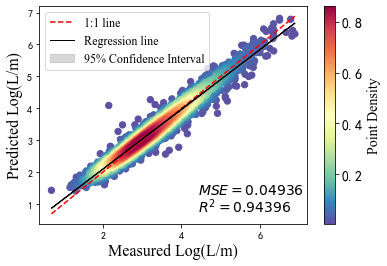

In [307]:
from scipy.stats import gaussian_kde
from statistics import mean
import matplotlib

#test_mse=0.05149
#test_r2=0.94273

def slope(xs, ys):
    m = (((mean(xs) * mean(ys)) - mean(xs * ys)) / ((mean(xs) * mean(xs)) - mean(xs * xs)))
    b = mean(ys) - m * mean(xs)
    return m, b
k, b = slope(y_test_label,final_test_pred)
regression_line = []
for a in y_test_label:
    regression_line.append((k * a) + b)
    
# 样本数量
n = len(y_test_label)
# 95%置信区间对应的z值（样本量大时可直接用1.96）
t_value = 1.96
residuals = final_test_pred - (k * y_test_label + b)
std_dev = np.std(residuals, ddof=1)  # ddof=1 使用无偏估计
std_err = std_dev / np.sqrt(n)
margin_of_error = t_value * std_err
lower_confidence_bound = regression_line - margin_of_error
upper_confidence_bound = regression_line + margin_of_error


xy = np.vstack([y_test_label,final_test_pred])
z = gaussian_kde(xy)(xy)
idx = np.argsort(z)


y_test_label = np.asarray(y_test_label)
final_test_pred = np.asarray(final_test_pred)

y_test_label1, final_test_pred1, z = y_test_label[idx], final_test_pred[idx], z[idx]

fig, ax = plt.subplots()
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14

# 散点密度图
sc = ax.scatter(y_test_label1, final_test_pred1, c=z, s=40, cmap='Spectral_r')

# 自动1:1线
min_val = min(y_test_label1.min(), final_test_pred1.min())
max_val = max(y_test_label1.max(), final_test_pred1.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r', lw=1.5, linestyle='--', label='1:1 line')

# 文字说明
ax.text(min_val + 0.6*(max_val - min_val),
        min_val + 0.1*(max_val - min_val),
        '$MSE=%.5f$' % test_mse,
        family='Times New Roman')

ax.text(min_val + 0.6*(max_val - min_val),
        min_val + 0.01*(max_val - min_val),
        '$R^2=%.5f$' % test_r2,
        family='Times New Roman')

# 回归线与置信区间
ax.plot(y_test_label, regression_line, 'black', lw=1, label='Regression line')
#ax.plot(y_test_label, lower_confidence_bound, linestyle='--', color='black', dashes=(1, 10), label='95% Confidence Interval')
#ax.plot(y_test_label, upper_confidence_bound, linestyle='--', color='black', dashes=(1, 10))
plt.fill_between(
    y_test_label,
    lower_confidence_bound,
    upper_confidence_bound,
    color='gray', alpha=0.3, label='95% Confidence Interval'
)

# 颜色条
cbar = plt.colorbar(sc)
cbar.set_label('Point Density', family='Times New Roman')

# 坐标轴与标题
ax.set_xlabel("Measured Log(L/m)", fontsize=16, family='Times New Roman')
ax.set_ylabel("Predicted Log(L/m)", fontsize=16, family='Times New Roman')
ax.legend(loc="upper left", prop={'family': 'Times New Roman', 'size': 12})
# ax.set_title("Ensemble Model Scatter Density Plot of Slip Distance",
#              fontsize=14, family='Times New Roman')

# 设置等比例坐标（确保1:1线对齐）
#ax.set_aspect('equal', adjustable='box')

plt.savefig("ensemble_model_scatter_density_plot.png", dpi=300, bbox_inches='tight')
plt.show()

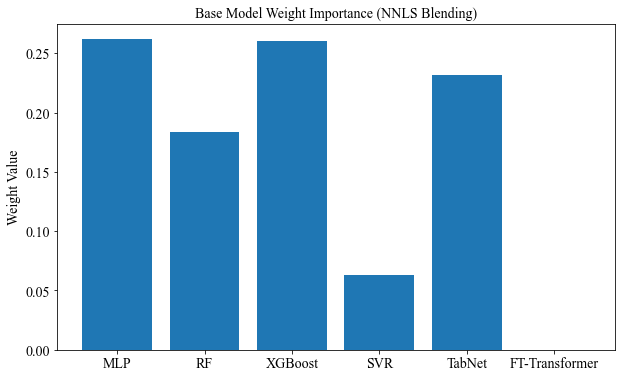

处理模型 0: MLPRegressor


ExactExplainer explainer: 2658it [00:49, 47.36it/s]                            


处理模型 1: RandomForestRegressor
处理模型 2: XGBRegressor
处理模型 3: SVR


ExactExplainer explainer: 2658it [3:21:55,  4.56s/it]                          


处理模型 4: TabNetRegressor


ExactExplainer explainer: 2658it [06:45,  6.42it/s]                            


处理模型 5: TabularModel


  0%|          | 0/2657 [00:00<?, ?it/s]

In [308]:
import matplotlib.pyplot as plt

# 设置新罗马字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

model_objects = [mx, RF, Xgb, svr_model, final_tabnet, final_model]  # 需要保证这6个模型对象存在
selected_names = [model_names[i] for i in top_idx]

plt.figure(figsize=(10, 6))
plt.bar(selected_names, weights)
plt.title("Base Model Weight Importance (NNLS Blending)", fontfamily='Times New Roman', fontsize=14)
plt.ylabel("Weight Value", fontfamily='Times New Roman')
plt.xticks(fontfamily='Times New Roman')
plt.yticks(fontfamily='Times New Roman')
plt.savefig('mixed_Base Model Weight Importance.png', dpi=300, bbox_inches='tight')
plt.show()
# ======================
# 计算并融合 SHAP 值
# ======================
# 原始特征名
feature_names = ['H','V','As','θ','Wsm']

shap_values_list = []

for i, model in zip(top_idx, [model_objects[i] for i in top_idx]):
    model_type = type(model).__name__
    print(f"处理模型 {i}: {model_type}")
    
    if hasattr(model, "predict"):
        if "Forest" in str(type(model)) or "XGB" in str(type(model)):
            X_df = pd.DataFrame(X_test, columns=feature_names)
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_df)
            vals = shap_values.values
            
        elif "TabularModel" in str(type(model)):
            
            try:
                model_features = model.config.continuous_cols + model.config.categorical_cols
            except AttributeError:
                model_features = model.config.data_config.continuous_cols + model.config.data_config.categorical_cols

            X_df_model = pd.DataFrame(X_test, columns=model_features)

            def model_predict(x):
                if not isinstance(x, pd.DataFrame):
                    x = pd.DataFrame(x, columns=model_features)
                return model.predict(x).to_numpy()

            explainer = shap.KernelExplainer(model_predict, X_df_model)
            shap_values = explainer(X_df_model)
            vals = shap_values.values[:, :len(feature_names)]

        else:
            #X_df = pd.DataFrame(X_test, columns=feature_names)
            def model_predict(x):
                return model.predict(x)

            explainer = shap.Explainer(model_predict, X_test)
            shap_values = explainer(X_test)
            vals = shap_values.values

        # ===== 去掉最后一维为1 =====
        vals = np.array(vals)
        if vals.shape[-1] == 1:
            vals = np.squeeze(vals, axis=-1)

        shap_values_list.append(vals)

# 加权融合 SHAP
stacked = np.stack(shap_values_list, axis=0)  # shape = (n_models, n_samples, n_features)
shap_values_ens = np.tensordot(weights, stacked, axes=(0,0))  # result shape (n_samples, n_features)

使用反标准化后的特征进行 SHAP 可视化

=== 2. Feature Impact Summary ===


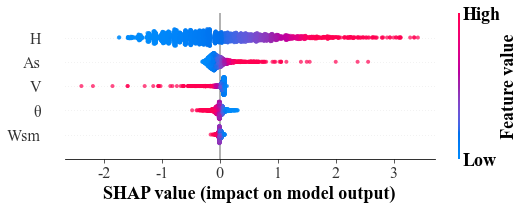


=== 3. Feature Dependence Plots ===
Top features by importance: ['H', 'As', 'V', 'θ']
False


<Figure size 432x432 with 0 Axes>

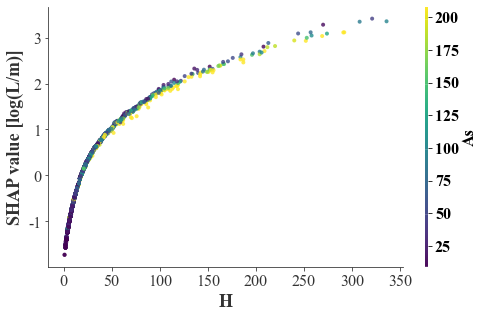

False


<Figure size 432x432 with 0 Axes>

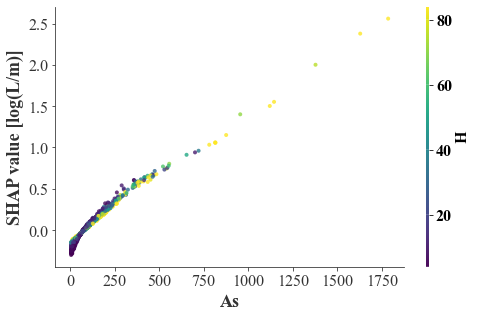

True


<Figure size 432x432 with 0 Axes>

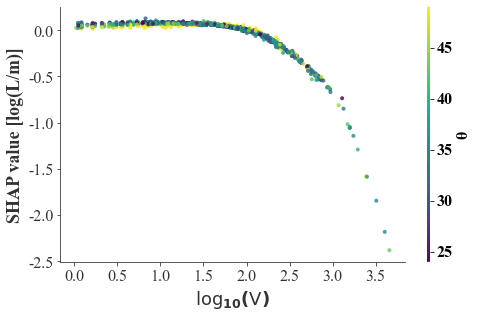

False


<Figure size 432x432 with 0 Axes>

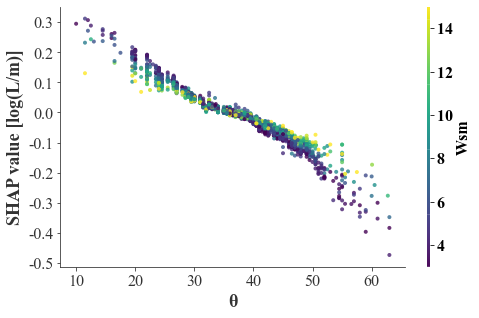

False


<Figure size 432x432 with 0 Axes>

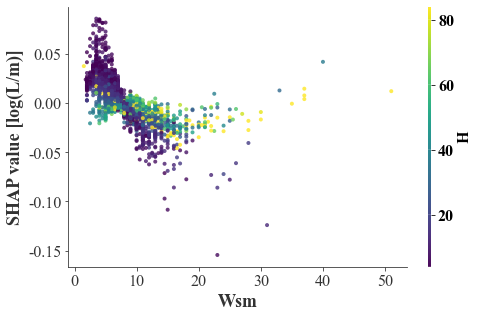

In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ======================

# 1. 反标准化（如可行）

# ======================
X_display = scaler.inverse_transform(X_test)
print("使用反标准化后的特征进行 SHAP 可视化")

# 定义特征名及单位（论文中显示用）

feature_names = ['H','V','As','θ','Wsm']

# 若模型预测 log(y)，则 SHAP 单位为 “log(目标单位)”

target_unit = "log(L/m)"  # 可改为 “m” 或其他实际单位

X_test_df = pd.DataFrame(X_display, columns=feature_names)

# ======================

# 2. 全局特征重要性

# ======================

# print("\n=== 1. Global Feature Importance ===")
# plt.figure(figsize=(8, 5))
# shap.summary_plot(
# shap_values_ens,
# X_display,
# plot_type="bar",
# feature_names=feature_names,
# show=False,
# color_bar=True
# )
# plt.title("Global Feature Importance (SHAP)", fontsize=14, fontweight='bold')
# plt.xlabel(f"Mean(|SHAP value|) [{target_unit}]", fontsize=12)
# plt.tight_layout()
# plt.savefig('mixed_shap_global_importance.png', dpi=300, bbox_inches='tight')
# plt.show()

# ======================

# 3. 特征影响汇总图

# ======================

print("\n=== 2. Feature Impact Summary ===")
plt.figure(figsize=(8,6))

# 绘制 SHAP summary plot
shap.summary_plot(
    shap_values_ens,
    X_display,
    feature_names=feature_names,
    show=False,
    alpha=0.7,
    color_bar=True
)

# 调整 x 轴标签
plt.xlabel("SHAP value (impact on model output)", fontsize=18, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# 调整 colorbar 字体和标签
fig = plt.gcf()
cbar_ax = fig.get_axes()[-1]  # summary_plot 的 colorbar 通常是最后一个轴
# 调整刻度字体大小和加粗
cbar_ax.tick_params(labelsize=18)
for tick in cbar_ax.get_yticklabels():
    tick.set_fontweight('bold')
# 调整 colorbar label 字号和加粗
if cbar_ax.yaxis.label is not None:
    cbar_ax.yaxis.label.set_fontsize(18)
    cbar_ax.yaxis.label.set_fontweight('bold')

# 调整边距
plt.tight_layout(pad=2.0)

# 保存高清图片
plt.savefig('mixed_shap_summary_plot.png', dpi=400, bbox_inches='tight')
plt.show()

# ======================

# 4. SHAP 依赖图

# ======================

print("\n=== 3. Feature Dependence Plots ===")
feature_importance = np.mean(np.abs(shap_values_ens), axis=0)
top_features_idx = np.argsort(feature_importance)[::-1]
top_features = [feature_names[i] for i in top_features_idx]
print(f"Top features by importance: {top_features[:4]}")
    
for feature in top_features[:5]:
    # 设置正方形画布
    plt.figure(figsize=(6,6))
    
    # 找到该特征在 feature_names 中的索引
    feature_idx = list(feature_names).index(feature)

    # 取出该列的原始数据
    x_data = X_display[:, feature_idx]
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)

    # 判断是否使用对数坐标
    use_log = (x_max / max(abs(x_min), 1e-10)) > 1000
    print(use_log)

    # 拷贝并进行必要的log变换
    X_display_mod = X_display.copy()
    if use_log:
        X_display_mod[:, feature_idx] = np.log10(np.maximum(x_data, 1e-12))
        xlabel = rf'$\mathbf{{\log_{{10}}(\mathrm{{{feature}}})}}$'

    else:
        xlabel = feature
        
    # 绘制 SHAP dependence plot
    shap.dependence_plot(
        ind=feature,
        shap_values=shap_values_ens,
        features=X_display_mod,
        feature_names=feature_names,
        show=False,
        alpha=0.8,
        cmap="viridis"
    )
    
    # 调整坐标轴标签和刻度字体
    plt.xlabel(xlabel, fontsize=18, fontweight='bold')
    plt.ylabel(f"SHAP value [{target_unit}]", fontsize=18, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    
    # 调整 colorbar 刻度和 label 字体
    fig = plt.gcf()
    cbar_ax = fig.get_axes()[-1]  # colorbar 通常是最后一个轴
    # 调整刻度字体大小和加粗
    cbar_ax.tick_params(labelsize=16)
    for tick in cbar_ax.get_yticklabels():
        tick.set_fontweight('bold')
    # 调整 colorbar label 字号和加粗
    if cbar_ax.yaxis.label is not None:
        cbar_ax.yaxis.label.set_fontsize(16)
        cbar_ax.yaxis.label.set_fontweight('bold')
    
    # 调整边距
    plt.tight_layout(pad=2.0)
    
    # 保存高清图片
    plt.savefig(f'mixed_shap_dependence_{feature}.png', dpi=400, bbox_inches='tight')
    plt.show()